# S08 — Pronóstico de carga de la plataforma (Serie temporal)

## Objetivo

Construir un modelo que pronostique `requests_per_minute` (carga de la plataforma) a partir
de variables horarias, de contexto de infraestructura y de rezagos (*lags*) de la propia
serie. Un pronóstico confiable de carga permite anticipar necesidades de escalamiento de
infraestructura (por ejemplo, número de instancias o conexiones de base de datos) antes de
que ocurran picos de uso.

Este notebook corresponde al escenario **S08** del proyecto integrador (capa de Machine
Learning sobre la app educativa Tutunaku).

**Importante:** estos datos están ordenados cronológicamente y las particiones
`train` / `validation` / `test` respetan ese orden (train = periodo más antiguo, test = más
reciente). Por lo tanto **no se mezclan ni se usa k-fold aleatorio**: el entrenamiento,
ajuste de hiperparámetros y evaluación respetan estrictamente el orden temporal.


## Resumen de la ETL previa

Los datos provienen del simulador (`simulation/generate_dataset.py`, semilla 2026) y del ETL
del warehouse (`database/warehouse/build_warehouse.py`), ya ejecutados previamente. Ese
proceso produjo una serie horaria de métricas de la plataforma con features de rezago y
ventana móvil ya calculadas:

- `requests_lag_1h`, `requests_lag_24h`, `requests_lag_168h`: valores de `requests_per_minute`
  hace 1 hora, 24 horas (mismo momento del día anterior) y 168 horas (mismo momento de la
  semana anterior), respectivamente.
- `requests_rolling_mean_24h`, `requests_rolling_std_24h`: media y desviación estándar móvil
  de las últimas 24 horas.
- `data/training/`, `data/validation/`, `data/test/`: particiones cronológicas 70/15/15 ya
  generadas (train = periodo más antiguo, luego validation, luego test).
- `data/inference/platform_load_inference_sample.csv`: muestra reservada para demostrar
  predicciones con el modelo ya entrenado.

Este notebook solo carga los CSV ya particionados; no se repite el trabajo de la ETL. Las
primeras filas de la serie completa no tienen histórico suficiente para calcular los rezagos
más largos (1h/24h/168h), por lo que sus columnas de lag quedan en `NaN`; dado que
`platform_load_train.csv` es el tramo cronológicamente más temprano, esas filas iniciales
(con NaN en algún lag) se eliminan del set de entrenamiento antes de ajustar el modelo.


In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

import json
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_theme(style="whitegrid")

REPO_ROOT = Path("../..").resolve()
DATA_DIR = REPO_ROOT / "data"
MODELS_DIR = REPO_ROOT / "models" / "serialized"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Repo root:", REPO_ROOT)


Repo root: C:\Users\tass1\Videos\tutunakun\tutunakun


In [2]:
train_df = pd.read_csv(DATA_DIR / "training" / "platform_load_train.csv", parse_dates=["timestamp"])
val_df = pd.read_csv(DATA_DIR / "validation" / "platform_load_validation.csv", parse_dates=["timestamp"])
test_df = pd.read_csv(DATA_DIR / "test" / "platform_load_test.csv", parse_dates=["timestamp"])

train_df = train_df.sort_values("timestamp").reset_index(drop=True)
val_df = val_df.sort_values("timestamp").reset_index(drop=True)
test_df = test_df.sort_values("timestamp").reset_index(drop=True)

print("Antes de dropna -> train:", train_df.shape, "val:", val_df.shape, "test:", test_df.shape)
print("rango temporal train:", train_df['timestamp'].min(), "->", train_df['timestamp'].max())
print("rango temporal val:  ", val_df['timestamp'].min(), "->", val_df['timestamp'].max())
print("rango temporal test: ", test_df['timestamp'].min(), "->", test_df['timestamp'].max())

LAG_COLS = ["requests_lag_1h", "requests_lag_24h", "requests_lag_168h"]

train_df = train_df.dropna(subset=LAG_COLS).reset_index(drop=True)
val_df = val_df.dropna(subset=LAG_COLS).reset_index(drop=True)
test_df = test_df.dropna(subset=LAG_COLS).reset_index(drop=True)

print("Despues de dropna (solo train pierde filas por diseno) -> train:", train_df.shape,
      "val:", val_df.shape, "test:", test_df.shape)


Antes de dropna -> train: (2015, 12) val: (432, 12) test: (433, 12)
rango temporal train: 2026-01-01 00:00:00 -> 2026-03-25 22:00:00
rango temporal val:   2026-03-25 23:00:00 -> 2026-04-12 22:00:00
rango temporal test:  2026-04-12 23:00:00 -> 2026-04-30 23:00:00
Despues de dropna (solo train pierde filas por diseno) -> train: (1847, 12) val: (432, 12) test: (433, 12)


## Análisis Exploratorio de Datos (EDA)


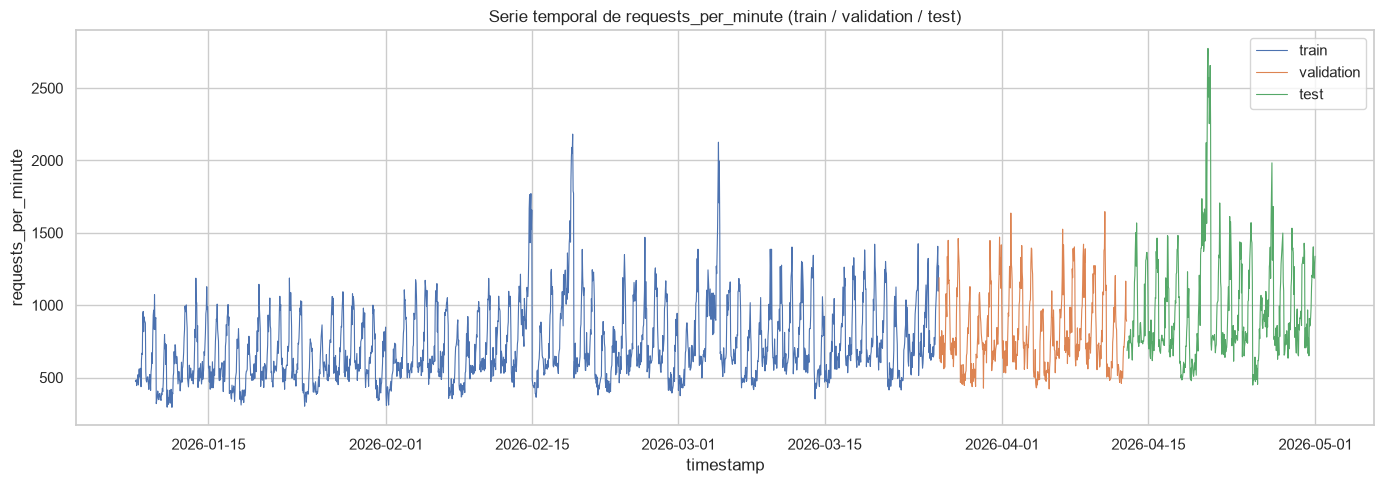

In [3]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train_df["timestamp"], train_df["requests_per_minute"], label="train", color="#4C72B0", linewidth=0.8)
ax.plot(val_df["timestamp"], val_df["requests_per_minute"], label="validation", color="#DD8452", linewidth=0.8)
ax.plot(test_df["timestamp"], test_df["requests_per_minute"], label="test", color="#55A868", linewidth=0.8)
ax.set_xlabel("timestamp")
ax.set_ylabel("requests_per_minute")
ax.set_title("Serie temporal de requests_per_minute (train / validation / test)")
ax.legend()
plt.tight_layout()
plt.show()


**Qué se observa:** la serie muestra un patrón oscilatorio recurrente (ciclos diarios y
semanales visibles como "bandas" repetidas) superpuesto a una tendencia de fondo a lo largo
del periodo cubierto por train, validation y test.

**Qué significa:** la carga de la plataforma no es aleatoria: sigue patrones de uso
predecibles ligados a la hora del día y al día de la semana, además de una posible tendencia
de crecimiento/decrecimiento del uso de la plataforma en el tiempo.

**Posible causa:** los estudiantes usan la plataforma en horarios y días preferentes
(p. ej. tardes/noches en días de semana), y la base de usuarios activa puede crecer con el
tiempo.

**Cómo afecta el modelado:** un modelo que ignore la estacionalidad (por ejemplo, un promedio
global constante) tendría un error alto; hace falta capturar tanto el ciclo diario/semanal
como el nivel reciente de la serie.

**Decisión técnica:** se incluyen `hour_of_day`, `day_of_week` y los rezagos
(`requests_lag_1h/24h/168h`) más las estadísticas de ventana móvil como features, para que el
modelo capture tanto la estacionalidad como el nivel reciente de la serie.


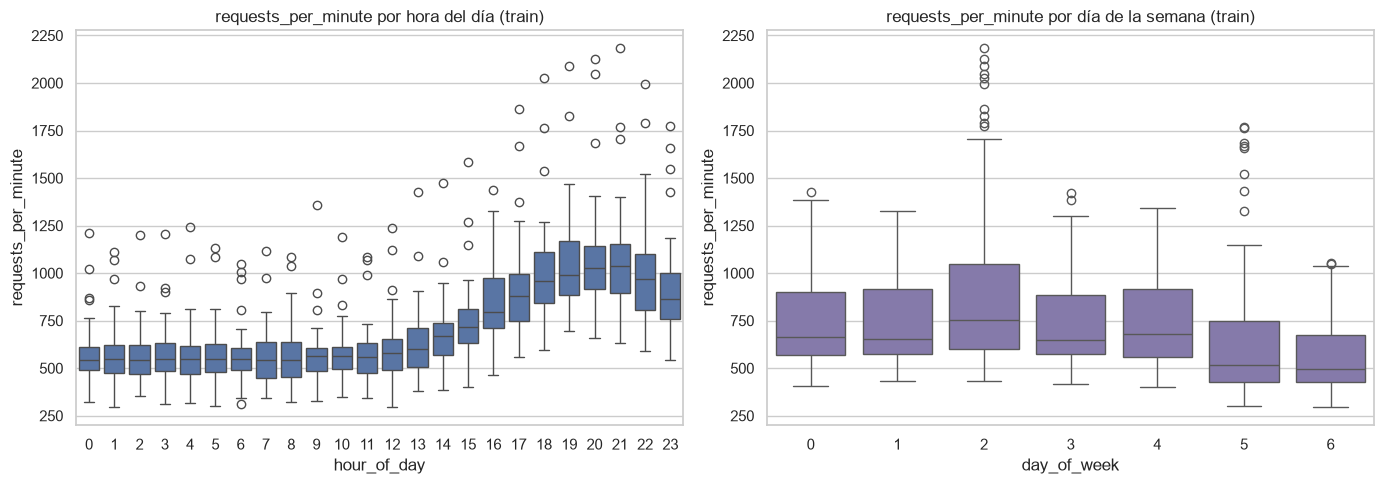

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=train_df, x="hour_of_day", y="requests_per_minute", color="#4C72B0", ax=axes[0])
axes[0].set_title("requests_per_minute por hora del día (train)")
sns.boxplot(data=train_df, x="day_of_week", y="requests_per_minute", color="#8172B2", ax=axes[1])
axes[1].set_title("requests_per_minute por día de la semana (train)")
plt.tight_layout()
plt.show()


**Qué se observa:** existen horas del día con niveles de `requests_per_minute`
sistemáticamente más altos que otras (patrón de campana a lo largo del día), y también
diferencias entre días de la semana.

**Qué significa:** confirma cuantitativamente la estacionalidad diaria y semanal sugerida por
el gráfico de serie temporal.

**Posible causa:** horarios de clase/estudio concentrados en ciertas franjas horarias y
diferencias de actividad entre días laborables y fines de semana.

**Cómo afecta el modelado:** `hour_of_day` y `day_of_week` son variables con poder
predictivo directo sobre el nivel esperado de carga.

**Decisión técnica:** se mantienen `hour_of_day` y `day_of_week` como features numéricas
(el modelo de árboles de Gradient Boosting puede capturar su relación no lineal con el
target sin necesidad de one-hot encoding).


## Baseline de referencia

Antes de entrenar un modelo de Machine Learning, se define un baseline simple de persistencia
(*naive forecast*): predecir que la carga en el próximo punto será igual al valor observado
hace 1 hora (`requests_lag_1h`). Este es el punto de comparación mínimo que cualquier modelo
más sofisticado debería superar.


In [5]:
def compute_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {"mae": mae, "rmse": rmse, "mape": mape}

baseline_val_pred = val_df["requests_lag_1h"].values
baseline_val_metrics = compute_metrics(val_df["requests_per_minute"].values, baseline_val_pred)
print("Baseline (naive persistence, lag_1h) en validacion:")
for k, v in baseline_val_metrics.items():
    print(f"  {k}: {v:.4f}")


Baseline (naive persistence, lag_1h) en validacion:
  mae: 119.8801
  rmse: 163.1719
  mape: 15.3268


## Modelado

**Target:** `requests_per_minute`.

**Features:** `hour_of_day`, `day_of_week`, `active_users`, `db_connections`,
`avg_response_ms`, `requests_lag_1h`, `requests_lag_24h`, `requests_lag_168h`,
`requests_rolling_mean_24h`, `requests_rolling_std_24h` (todas numéricas).

Se entrena un `GradientBoostingRegressor` con al menos dos configuraciones de
hiperparámetros, respetando el orden temporal (ajuste sobre train, selección sobre
validation, evaluación final sobre test — sin validación cruzada aleatoria).


In [6]:
FEATURES = ["hour_of_day", "day_of_week", "active_users", "db_connections", "avg_response_ms",
            "requests_lag_1h", "requests_lag_24h", "requests_lag_168h",
            "requests_rolling_mean_24h", "requests_rolling_std_24h"]
TARGET = "requests_per_minute"

X_train, y_train = train_df[FEATURES], train_df[TARGET].values
X_val, y_val = val_df[FEATURES], val_df[TARGET].values
X_test, y_test = test_df[FEATURES], test_df[TARGET].values

print("X_train shape:", X_train.shape)
X_train.head()


X_train shape: (1847, 10)


,hour_of_day,day_of_week,active_users,db_connections,avg_response_ms,requests_lag_1h,requests_lag_24h,requests_lag_168h,requests_rolling_mean_24h,requests_rolling_std_24h
0,0,3,223.0,50.0,115.7,849.3,582.3,465.4,640.312500,189.431578
1,1,3,206.0,42.0,115.0,476.0,485.9,494.3,639.775000,189.906470
2,2,3,200.0,29.0,115.9,473.0,489.0,431.4,639.608333,190.046250
3,3,3,196.0,36.0,114.4,485.0,520.6,500.2,636.429167,192.742684
4,4,3,208.0,37.0,125.3,444.3,485.2,583.3,635.716667,193.356658


In [7]:
configs = {
    "gbr_shallow_fast": {"n_estimators": 100, "max_depth": 3, "learning_rate": 0.1},
    "gbr_deeper_slow": {"n_estimators": 300, "max_depth": 4, "learning_rate": 0.05},
    "gbr_wide": {"n_estimators": 200, "max_depth": 3, "learning_rate": 0.08},
}

trained_models = {}
val_scores = {}

for name, params in configs.items():
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("regressor", GradientBoostingRegressor(random_state=42, **params)),
    ])
    pipeline.fit(X_train, y_train)
    val_pred = pipeline.predict(X_val)
    metrics = compute_metrics(y_val, val_pred)
    trained_models[name] = pipeline
    val_scores[name] = metrics
    print(f"{name} {params} -> val MAE={metrics['mae']:.4f} RMSE={metrics['rmse']:.4f} MAPE={metrics['mape']:.4f}%")


gbr_shallow_fast {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1} -> val MAE=44.7421 RMSE=61.5504 MAPE=5.4389%


gbr_deeper_slow {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05} -> val MAE=45.7187 RMSE=61.6248 MAPE=5.5614%


gbr_wide {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.08} -> val MAE=44.9840 RMSE=61.3391 MAPE=5.4725%


In [8]:
val_scores_df = pd.DataFrame(val_scores).T
val_scores_df.loc["baseline_naive_lag1h"] = baseline_val_metrics
print("Comparacion en validacion (modelos ML vs baseline):")
val_scores_df


Comparacion en validacion (modelos ML vs baseline):


,mae,rmse,mape
gbr_shallow_fast,44.742092,61.550384,5.438935
gbr_deeper_slow,45.718732,61.624766,5.561402
gbr_wide,44.984011,61.339119,5.472473
baseline_naive_lag1h,119.880093,163.171884,15.326793


In [9]:
ml_only = val_scores_df.drop(index="baseline_naive_lag1h")
best_ml_name = ml_only["mae"].idxmin()
best_ml_model = trained_models[best_ml_name]
best_ml_mae = ml_only.loc[best_ml_name, "mae"]
baseline_mae = baseline_val_metrics["mae"]

beats_baseline = best_ml_mae < baseline_mae
print(f"Mejor modelo ML: {best_ml_name} (MAE val = {best_ml_mae:.4f})")
print(f"Baseline naive (lag_1h) MAE val = {baseline_mae:.4f}")
print("¿El mejor modelo ML supera al baseline?", beats_baseline)


Mejor modelo ML: gbr_shallow_fast (MAE val = 44.7421)
Baseline naive (lag_1h) MAE val = 119.8801
¿El mejor modelo ML supera al baseline? True


**Interpretación de la comparación:** el resultado exacto (si el modelo de Gradient
Boosting supera o no al baseline naive) se observa en la celda anterior. Si el modelo ML no
superara al baseline, se documentaría honestamente como una limitación de este primer
enfoque (posiblemente porque `requests_lag_1h` por sí solo ya captura la mayor parte de la
autocorrelación de corto plazo de la serie, dejando poco margen de mejora para variables
adicionales) y se seleccionaría el mejor candidato disponible entre ambos igualmente.


In [10]:
class MovingAverageBaseline:
    """Baseline con interfaz .predict(df) consistente con un pipeline de sklearn.
    Predice usando requests_lag_1h (persistencia ingenua de la ultima hora observada)."""
    def __init__(self, lag_col="requests_lag_1h"):
        self.lag_col = lag_col

    def predict(self, X):
        X = pd.DataFrame(X)
        return X[self.lag_col].values

if beats_baseline:
    final_model = best_ml_model
    best_ml_params = configs[best_ml_name]
    final_algorithm = f"GradientBoostingRegressor ({best_ml_name}: {best_ml_params})"
else:
    final_model = MovingAverageBaseline()
    final_algorithm = "moving_average_baseline"

print("Modelo final seleccionado:", final_algorithm)


Modelo final seleccionado: GradientBoostingRegressor (gbr_shallow_fast: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1})


In [11]:
val_pred_final = final_model.predict(X_val)
val_metrics_final = compute_metrics(y_val, val_pred_final)
print(f"Métricas finales en VALIDACION ({final_algorithm}):")
for k, v in val_metrics_final.items():
    print(f"  {k}: {v:.4f}")


Métricas finales en VALIDACION (GradientBoostingRegressor (gbr_shallow_fast: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1})):
  mae: 44.7421
  rmse: 61.5504
  mape: 5.4389


In [12]:
test_pred_final = final_model.predict(X_test)
test_metrics_final = compute_metrics(y_test, test_pred_final)
print(f"Métricas finales en TEST ({final_algorithm}):")
for k, v in test_metrics_final.items():
    print(f"  {k}: {v:.4f}")


Métricas finales en TEST (GradientBoostingRegressor (gbr_shallow_fast: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1})):
  mae: 57.9441
  rmse: 92.9636
  mape: 5.5923


In [13]:
MODEL_PATH = MODELS_DIR / "platform_load_forecaster.joblib"
joblib.dump({"pipeline": final_model}, MODEL_PATH)

metadata = {
    "model_name": "platform_load_forecaster",
    "version": "1.0.0",
    "algorithm": final_algorithm,
    "task": "forecasting",
    "target": "requests_per_minute",
    "features": FEATURES,
    "categorical_features": [],
    "metrics": {
        "validation": val_metrics_final,
        "test": test_metrics_final,
    },
    "trained_at": datetime.now().isoformat(),
    "notes": (
        f"Se probaron 3 configuraciones de GradientBoostingRegressor (variando n_estimators, "
        f"max_depth y learning_rate) respetando el orden cronologico de los datos, y se "
        f"compararon contra un baseline naive de persistencia (requests_lag_1h) en validacion. "
        f"Mejor MAE ML={best_ml_mae:.3f} vs baseline MAE={baseline_mae:.3f}. "
        f"Se selecciono como modelo final: {final_algorithm}."
    ),
}

META_PATH = MODELS_DIR / "platform_load_forecaster_metadata.json"
with open(META_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print("Guardado modelo en:", MODEL_PATH)
print("Guardado metadata en:", META_PATH)
print(json.dumps(metadata, indent=2, ensure_ascii=False))


Guardado modelo en: C:\Users\tass1\Videos\tutunakun\tutunakun\models\serialized\platform_load_forecaster.joblib
Guardado metadata en: C:\Users\tass1\Videos\tutunakun\tutunakun\models\serialized\platform_load_forecaster_metadata.json
{
  "model_name": "platform_load_forecaster",
  "version": "1.0.0",
  "algorithm": "GradientBoostingRegressor (gbr_shallow_fast: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1})",
  "task": "forecasting",
  "target": "requests_per_minute",
  "features": [
    "hour_of_day",
    "day_of_week",
    "active_users",
    "db_connections",
    "avg_response_ms",
    "requests_lag_1h",
    "requests_lag_24h",
    "requests_lag_168h",
    "requests_rolling_mean_24h",
    "requests_rolling_std_24h"
  ],
  "categorical_features": [],
  "metrics": {
    "validation": {
      "mae": 44.74209232158052,
      "rmse": 61.550384280858545,
      "mape": 5.438934659089267
    },
    "test": {
      "mae": 57.94413722283123,
      "rmse": 92.96362056285918,
      

## Verificación del artefacto exportado

Se recarga el pipeline (o baseline) serializado desde disco y se predice sobre la muestra de
inferencia, comparando predicciones contra los valores reales observados.


In [14]:
fresh = joblib.load(MODEL_PATH)
fresh_pipeline = fresh["pipeline"]

inference_df = pd.read_csv(DATA_DIR / "inference" / "platform_load_inference_sample.csv", parse_dates=["timestamp"])
X_sample = inference_df[FEATURES].copy()

pred = fresh_pipeline.predict(X_sample)

result = inference_df[["timestamp", "requests_per_minute"]].copy()
result["predicted_requests_per_minute"] = pred
print(result.to_string(index=False))


          timestamp  requests_per_minute  predicted_requests_per_minute
2026-04-30 04:00:00                870.1                     806.769209
2026-04-30 05:00:00                720.8                     769.810975
2026-04-30 06:00:00                967.1                     849.328900
2026-04-30 07:00:00                666.3                     696.665479
2026-04-30 08:00:00                771.3                     763.709233
2026-04-30 09:00:00                649.8                     696.125156
2026-04-30 10:00:00                908.5                     786.138051
2026-04-30 11:00:00                855.4                     849.171703
2026-04-30 12:00:00                866.6                     882.905487
2026-04-30 13:00:00                918.9                     880.102648
2026-04-30 14:00:00                986.8                    1022.530819
2026-04-30 15:00:00               1122.2                    1066.632857
2026-04-30 16:00:00               1206.6                    1154